# **What is a Neural Network?**

A **neural network** is a machine learning model inspired by the human brain. It is made up of layers of neurons, where each neuron performs a simple computation. Neural networks are used for solving complex tasks like classification, regression, image recognition, and more.

The simplest type of neural network is a **Perceptron**, which is a single-layer neural network that can solve linearly separable problems.

In this notebook:
1. We will implement a **Perceptron** from scratch.
2. We will use **NumPy** to build activation functions.
3. Understand how a Perceptron works step by step.


# **What is a Perceptron?**

A **Perceptron** is the basic building block of a neural network. It consists of:
1. **Inputs**: Features of the data.
2. **Weights**: Parameters that determine the influence of each input.
3. **Bias**: An additional parameter to adjust the output.
4. **Activation Function**: A function that decides whether the neuron "fires" or not.

The output of a Perceptron is computed as:
$$
y = f(W \cdot X + b)
$$
Where:
- $ W $: Weights
- $ X $: Inputs
- $ b $: Bias
- $ f $: Activation function (e.g., step function, sigmoid, ReLU)


In [1]:
import numpy as np


## **Activation Function**

The activation function determines the output of a neuron. For a simple perceptron, we use the **step function**, which outputs 1 if the input is greater than a threshold (e.g., 0), and 0 otherwise.

### **Step Function:**

$$
f(x) = \begin{cases}
1 & \text{if } x \geq 0 \\
0 & \text{if } x < 0
\end{cases}
$$

The step function introduces a non-linearity by "activating" the neuron only when the input exceeds a threshold. It is commonly used in the perceptron for binary classification tasks.


In [2]:
# Step activation function
def step_function(x):
    return np.where(x >= 0, 1, 0)


## **Perceptron Implementation**
The perceptron computes the weighted sum of inputs and applies the activation function to decide the output.


In [3]:
class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialize weights and bias
        self.weights = np.random.randn(input_dim)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def predict(self, X):
        # Compute the linear combination: W·X + b
        linear_output = np.dot(X, self.weights) + self.bias
        # Apply the step activation function
        return step_function(linear_output)

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            for xi, target in zip(X, y):
                # Predict the output
                prediction = self.predict(xi)
                # Compute the error
                error = target - prediction
                # Update weights and bias
                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error


## **Training the Perceptron**

Let us train the Perceptron on a simple binary classification problem: the **logical AND gate**.


In [4]:
# Input data (AND gate)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # Output of AND gate

# Create a Perceptron object
perceptron = Perceptron(input_dim=2, learning_rate=0.1)

# Train the Perceptron
perceptron.train(X, y, epochs=10)

# Test the Perceptron
print("Predictions:")
for xi, target in zip(X, y):
    prediction = perceptron.predict(xi)
    print(f"Input: {xi}, Target: {target}, Prediction: {prediction}")


Predictions:
Input: [0 0], Target: 0, Prediction: 0
Input: [0 1], Target: 0, Prediction: 0
Input: [1 0], Target: 0, Prediction: 0
Input: [1 1], Target: 1, Prediction: 1


# **Activation Functions in Neural Networks**

Activation functions introduce non-linearity into the network, allowing it to solve more complex problems.

### **Common Activation Functions**
1. **Step Function**: Outputs 0 or 1 based on a threshold.
2. **Sigmoid Function**: Maps input to a value between 0 and 1.
3. **ReLU (Rectified Linear Unit)**: Outputs 0 for negative inputs and the input itself for positive inputs.

### **Mathematical Definitions**
1. **Sigmoid Function**:
$$
f(x) = \frac{1}{1 + e^{-x}}
$$

2. **ReLU Function**:
$$
f(x) = \max(0, x)
$$

3. **Step Function**:
$$
f(x) = \begin{cases}
1 & \text{if } x \geq 0 \\
0 & \text{if } x < 0
\end{cases}
$$

In [5]:
# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ReLU activation function
def relu(x):
    return np.maximum(0, x)


## **Visualizing Activation Functions**

Let's plot these activation functions to understand their behavior.


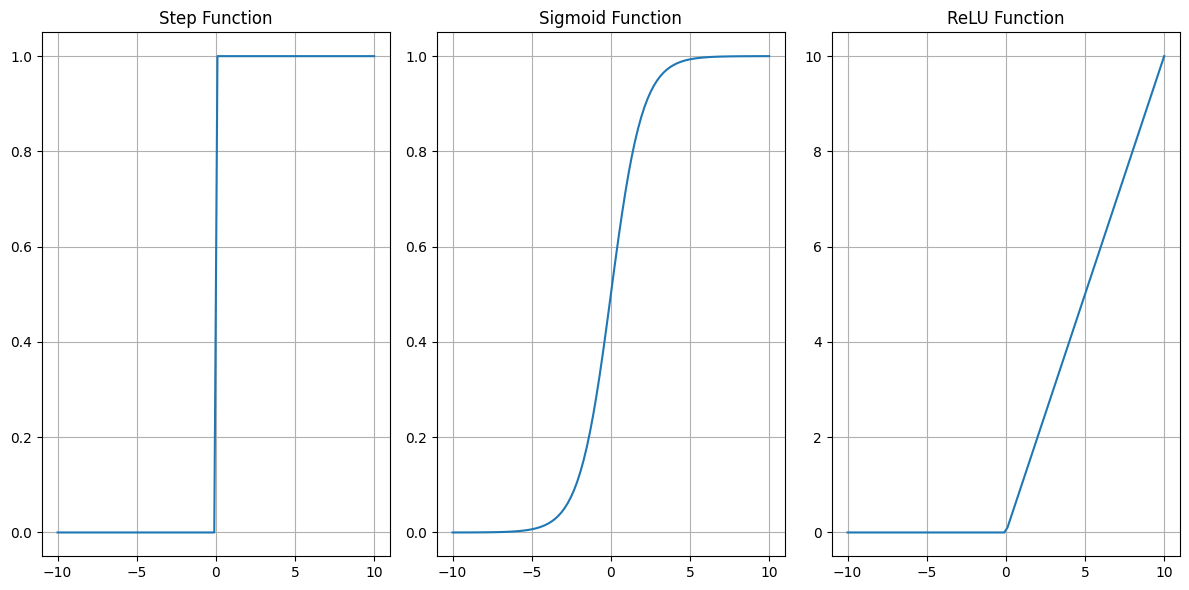

In [6]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

# Plot activation functions
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.plot(x, step_function(x), label="Step")
plt.title("Step Function")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.title("Sigmoid Function")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(x, relu(x), label="ReLU")
plt.title("ReLU Function")
plt.grid()

plt.tight_layout()
plt.show()


# **Conclusion**

In this notebook, we introduced:
1. **What is a Perceptron**:
   - The simplest type of neural network.
   - Components: Inputs, weights, bias, and activation function.
2. **Implemented a Perceptron**:
   - Trained it to model the logical AND gate.
3. **Activation Functions**:
   - Introduced common activation functions (Step, Sigmoid, ReLU).
   - Implemented them from scratch and visualized their behavior.

### **Next Steps**
1. Extend the perceptron to a multi-layer neural network (MLP).
2. Experiment with activation functions for solving non-linear problems.
3. Use deep learning frameworks like TensorFlow or PyTorch for building more complex models.


# **Perceptron with Keras and PyTorch**

While building neural networks from scratch provides deep insights into their functioning, using frameworks like **Keras** and **PyTorch** makes the process simpler, more efficient, and faster. These frameworks abstract many low-level operations, allowing you to focus on designing and training your model.

In this section:
1. We'll implement a simple perceptron using **Keras**.
2. We'll implement the same perceptron using **PyTorch**.
3. We'll highlight how easy it is to build and train neural networks using these frameworks.


## **Using Keras**

Keras provides a high-level API for defining and training neural networks. We'll use the **Sequential API** to build a single-layer perceptron for the AND gate problem.

### Steps:
1. Define the model using `Sequential()`.
2. Add a dense (fully connected) layer.
3. Compile the model with an optimizer and loss function.
4. Train the model using `fit()` and evaluate predictions.

### Implementation:


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# Input data (AND gate)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])  # AND gate output

# Step 1: Define the model
model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))  # Single perceptron layer

# Step 2: Compile the model
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the model
model.fit(X, y, epochs=100, verbose=0)  # Train for 100 epochs

# Step 4: Test the model
print("Predictions:")
predictions = model.predict(X)
for i, pred in enumerate(predictions):
    print(f"Input: {X[i]} -> Predicted Output: {np.round(pred)}")


c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Input: [0 0] -> Predicted Output: [0.]
Input: [0 1] -> Predicted Output: [0.]
Input: [1 0] -> Predicted Output: [0.]
Input: [1 1] -> Predicted Output: [0.]


## **Using PyTorch**

PyTorch provides a dynamic computational graph, making it very flexible for neural network implementation. We'll define the perceptron using the `torch.nn.Module` class.

### Steps:
1. Define the model as a class inheriting from `torch.nn.Module`.
2. Add a single linear layer (equivalent to the perceptron).
3. Use the `torch.nn.BCELoss` (binary cross-entropy) as the loss function.
4. Train the model using an optimizer like SGD.

### Implementation:


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# Input data (AND gate)
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = torch.tensor([[0.0], [0.0], [0.0], [1.0]])

# Define the perceptron model
class Perceptron(nn.Module):
    def __init__(self):
        super(Perceptron, self).__init__()
        self.fc = nn.Linear(2, 1)  # Single layer with 2 inputs and 1 output
        self.activation = nn.Sigmoid()  # Sigmoid activation function

    def forward(self, x):
        x = self.fc(x)
        return self.activation(x)

# Initialize the model, loss function, and optimizer
model = Perceptron()
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Train the model
epochs = 100
for epoch in range(epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Test the model
print("Predictions:")
with torch.no_grad():
    predictions = model(X)
    for i, pred in enumerate(predictions):
        print(f"Input: {X[i].numpy()} -> Predicted Output: {torch.round(pred).item()}")


Predictions:
Input: [0. 0.] -> Predicted Output: 0.0
Input: [0. 1.] -> Predicted Output: 0.0
Input: [1. 0.] -> Predicted Output: 0.0
Input: [1. 1.] -> Predicted Output: 0.0


## **Keras vs PyTorch**

| Feature                | Keras                        | PyTorch                         |
|------------------------|------------------------------|---------------------------------|
| **Ease of Use**        | High-level, user-friendly API. | Low-level control and flexibility. |
| **Training**           | Automatically managed via `fit()`. | Requires manual training loops. |
| **Flexibility**        | Limited customizability.      | Highly customizable.            |
| **Best For**           | Beginners and quick prototyping. | Research and complex models.    |

### Observations:
1. **Keras** is beginner-friendly and requires minimal code to train a neural network.
2. **PyTorch** provides more control, making it ideal for advanced users and custom architectures.


# **Conclusion**

In this section:
1. We implemented a simple perceptron for the AND gate problem using both **Keras** and **PyTorch**.
2. We observed how frameworks simplify neural network implementation compared to building from scratch.
3. We highlighted the differences between Keras and PyTorch, helping learners choose the right framework for their needs.


# **Exploring Real-World Applications of Neural Networks in Various Industries**

Neural networks have revolutionized many industries by solving complex problems that were once considered impossible. By leveraging their ability to learn and generalize from data, neural networks power some of the most advanced technologies today. Below, we explore their applications across different industries.

---

## **1. Healthcare**

### **Applications:**
1. **Medical Imaging and Diagnosis**:
   - Neural networks, especially Convolutional Neural Networks (CNNs), are used for detecting diseases like cancer, pneumonia, and diabetic retinopathy from medical images (e.g., X-rays, MRIs).
   - Example: DeepMind’s neural network system detects over 50 eye diseases using retinal scans.

2. **Drug Discovery**:
   - Neural networks help predict how new drugs will interact with the human body, significantly reducing the time and cost of drug discovery.

3. **Personalized Medicine**:
   - Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks analyze patient histories to recommend personalized treatment plans.

---

## **2. Finance**

### **Applications:**
1. **Fraud Detection**:
   - Neural networks analyze transaction patterns to identify unusual activity, reducing fraudulent transactions.

2. **Stock Market Prediction**:
   - RNNs and LSTMs are used to model sequential data for predicting stock prices and market trends.

3. **Credit Scoring**:
   - Neural networks evaluate creditworthiness by analyzing historical repayment data and user profiles.

---

## **3. Retail and E-Commerce**

### **Applications:**
1. **Recommendation Systems**:
   - Neural networks power recommendation engines, suggesting products based on user behavior.
   - Example: Amazon and Netflix use neural networks to recommend products and movies, respectively.

2. **Customer Sentiment Analysis**:
   - Natural Language Processing (NLP) models based on neural networks analyze customer reviews to understand sentiment and improve services.

3. **Demand Forecasting**:
   - Neural networks predict product demand, helping optimize inventory management and supply chain operations.

---

## **4. Manufacturing**

### **Applications:**
1. **Predictive Maintenance**:
   - Neural networks analyze sensor data to predict equipment failure and schedule maintenance in advance.

2. **Quality Control**:
   - Neural networks detect defects in products by analyzing images, ensuring high-quality manufacturing.

3. **Robotics**:
   - Neural networks enable robots to learn tasks, improve efficiency, and adapt to changing environments in factories.

---

## **5. Transportation and Logistics**

### **Applications:**
1. **Autonomous Vehicles**:
   - CNNs and RNNs are integral to self-driving cars, enabling them to process visual input, detect objects, and make driving decisions.
   - Example: Tesla’s Autopilot system.

2. **Route Optimization**:
   - Neural networks optimize delivery routes, reducing time and fuel costs for logistics companies like FedEx and UPS.

3. **Traffic Prediction**:
   - Neural networks analyze real-time traffic data to predict congestion and suggest alternative routes.

---

## **6. Energy and Utilities**

### **Applications:**
1. **Energy Demand Forecasting**:
   - Neural networks predict electricity consumption patterns to optimize energy distribution.

2. **Smart Grids**:
   - Neural networks monitor grid performance and detect anomalies, improving grid efficiency and reliability.

3. **Renewable Energy Optimization**:
   - Neural networks predict weather patterns to optimize solar and wind energy generation.

---

## **7. Entertainment and Media**

### **Applications:**
1. **Content Recommendation**:
   - Neural networks power personalized content recommendations on platforms like YouTube, Spotify, and Netflix.

2. **Image and Video Enhancement**:
   - Generative Adversarial Networks (GANs) enhance image quality, restore old photos, and generate realistic video effects.

3. **Game AI**:
   - Neural networks create intelligent, adaptive non-player characters (NPCs) in video games.

---

## **8. Agriculture**

### **Applications:**
1. **Crop Monitoring**:
   - Neural networks analyze satellite and drone imagery to monitor crop health and detect diseases.

2. **Yield Prediction**:
   - Neural networks predict crop yield based on weather, soil conditions, and farming practices.

3. **Precision Farming**:
   - Neural networks guide smart irrigation systems and fertilizer application to optimize resource usage.

---

## **9. Education**

### **Applications:**
1. **Personalized Learning**:
   - Neural networks adapt educational content to the learner’s pace, strengths, and weaknesses.

2. **Automated Grading**:
   - Neural networks evaluate essays and assignments, saving time for educators.

3. **Language Translation**:
   - Neural networks power tools like Google Translate for real-time language translation, enhancing global education.

---

## **10. Cybersecurity**

### **Applications:**
1. **Threat Detection**:
   - Neural networks detect malware, phishing attacks, and other cybersecurity threats by analyzing network traffic.

2. **User Authentication**:
   - Neural networks enhance security through biometric authentication, such as facial recognition and voice recognition.

3. **Anomaly Detection**:
   - Neural networks identify unusual patterns in system logs, preventing cyber-attacks.

---

## **Conclusion**

Neural networks have transformed industries by enabling automation, improving efficiency, and solving complex problems. From healthcare and finance to agriculture and entertainment, their applications are vast and ever-growing.

### **Future Outlook**
As neural network architectures become more advanced and computational power increases, we can expect even greater breakthroughs in fields like quantum computing, space exploration, and personalized artificial intelligence.
